In [ ]:
import os
import gc
import numpy as np
import pandas as pd
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
folder_path = r'D:\clone\merged'

In [ ]:
def standardise(df):
    return (df - df.mean()) / (df.std() + 1e-9)

def load_and_aggregate_instability(cape_f, ki_f, tt_f):
    def preprocess(ds):
        if 'valid_time' in ds.coords: ds = ds.rename({'valid_time': 'time'})
        if 'expver' in ds.dims: ds = ds.mean(dim='expver')
        return ds.sortby('time')

    files = [cape_f, ki_f, tt_f]
    keys = ['cape', 'ki', 'tt']
    df_daily = pd.DataFrame()
    raw_data = {}

    for f, k in zip(files, keys):
        ds = preprocess(xr.open_dataset(os.path.join(folder_path, f)))
        var = list(ds.data_vars)[0]
        ts = ds[var].mean(dim=['latitude', 'longitude']).compute()
        raw_data[k] = ts
        df_daily[k] = ts.resample(time='1D').max().values
        if k == 'cape': df_daily.index = ts.resample(time='1D').max().time.values
        ds.close(); gc.collect()

    df_daily['cii'] = (standardise(df_daily['cape']) + standardise(df_daily['ki']) + standardise(df_daily['tt'])) / 3.0
    
    df_daily['severe'] = (df_daily['cii'] > 1.0).astype(float)
    
    df_monthly = df_daily.resample('ME').mean()
    df_yearly = df_daily.resample('YS').mean()
    clim = df_monthly.groupby(df_monthly.index.month).mean()
    
    df_monthly['month'] = df_monthly.index.month
    df_monthly['year'] = df_monthly.index.year
    df_monthly['cii_anom'] = df_monthly['cii'] - df_monthly['month'].map(clim['cii'])
    df_monthly['cape_anom'] = df_monthly['cape'] - df_monthly['month'].map(clim['cape'])

    return df_daily, df_monthly, df_yearly, clim, raw_data

In [18]:
c_f = 'convective_available_potential_energy (CAPE)_merged.nc'
k_f = 'k_index_merged.nc'
t_f = 'total_totals_index_merged.nc'

df_daily, df_monthly, df_yearly, clim, raw = load_and_aggregate_instability(c_f, k_f, t_f)
df_monthly.head()

,cape,ki,tt,cii,severe,month,year,cii_anom,cape_anom
1980-01-31,29.902786,8.092877,35.962696,-1.454254,0.000000,1,1980,-0.171727,-10.357895
1980-02-29,120.765549,20.567781,40.086693,-0.638103,0.000000,2,1980,0.229217,4.770645
1980-03-31,478.301025,25.878130,42.899925,-0.043525,0.000000,3,1980,0.198893,88.085876
1980-04-30,962.939209,30.002392,43.399277,0.390885,0.066667,4,1980,-0.021894,-26.494812
1980-05-31,1523.421509,33.994019,44.245235,0.886895,0.451613,5,1980,0.119694,104.204102


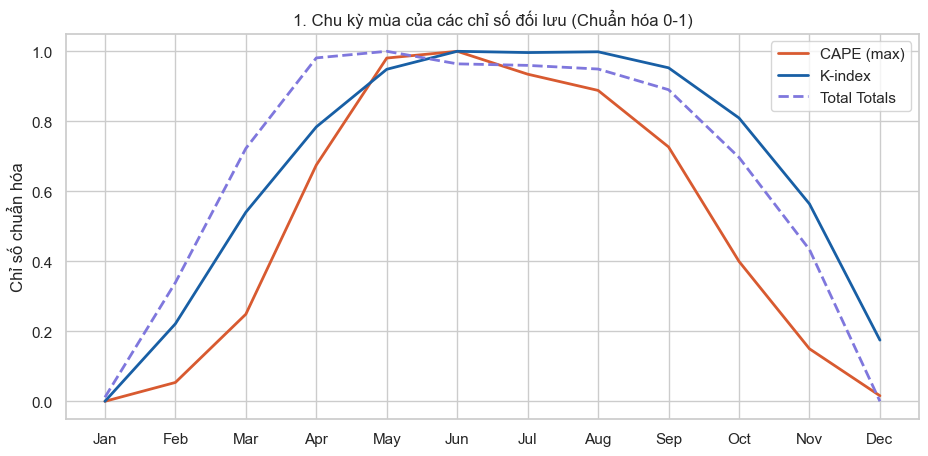

In [19]:
def minmax(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)

plt.figure(figsize=(11, 5))
plt.plot(clim.index, minmax(clim['cape']), color='#D85A30', lw=2, label='CAPE (max)')
plt.plot(clim.index, minmax(clim['ki']), color='#185FA5', lw=2, label='K-index')
plt.plot(clim.index, minmax(clim['tt']), color='#7F77DD', lw=2, ls='--', label='Total Totals')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.title("1. Chu kỳ mùa của các chỉ số đối lưu (Chuẩn hóa 0-1)")
plt.ylabel("Chỉ số chuẩn hóa")
plt.legend()
plt.show()

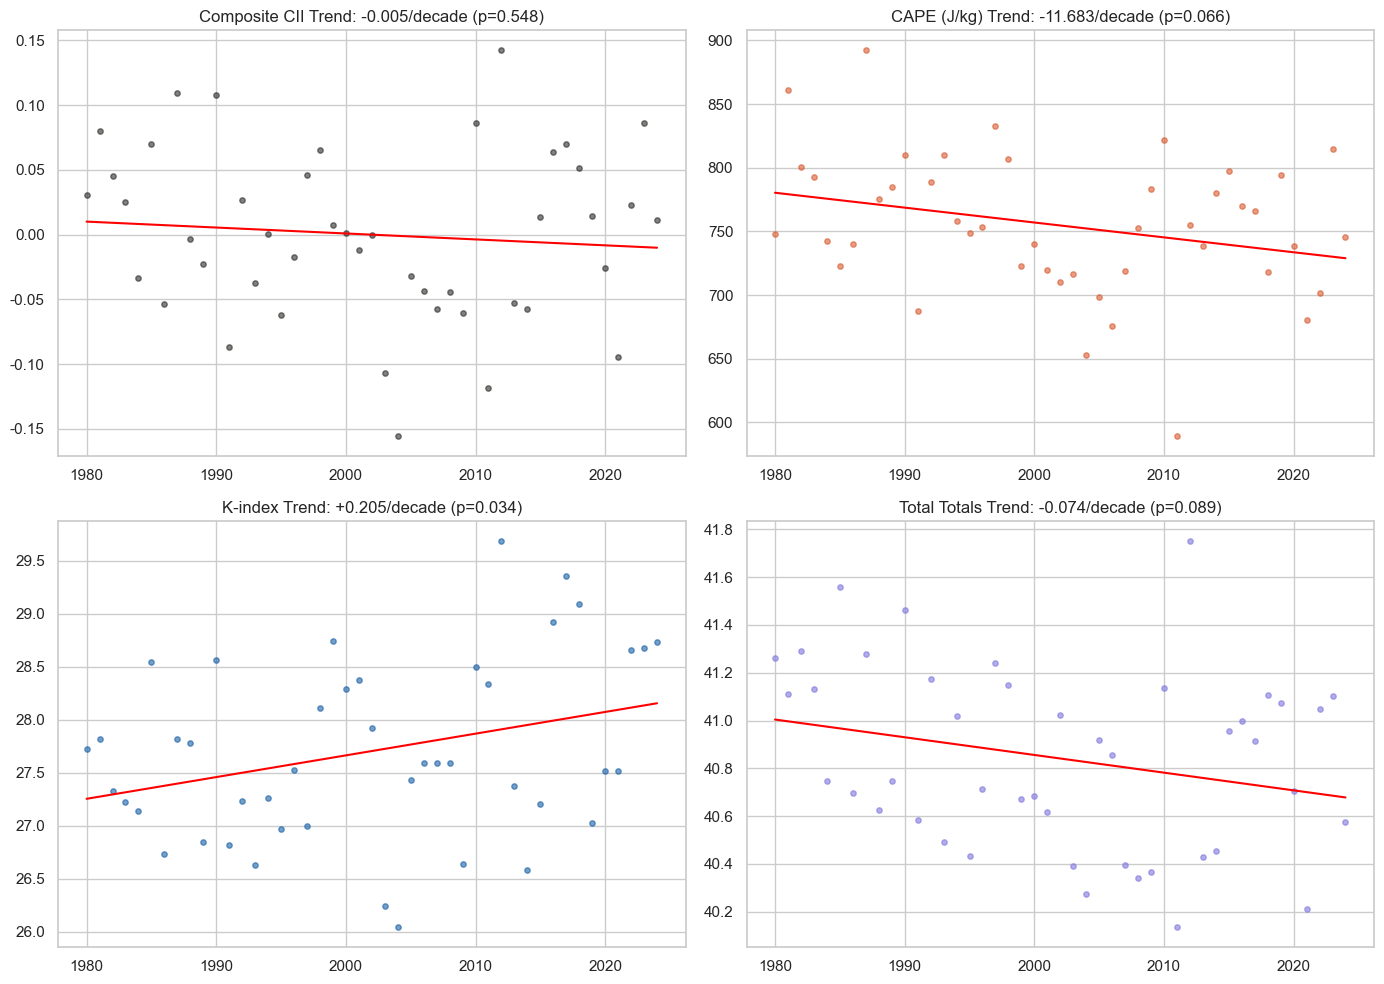

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = [('cii', 'Composite CII', '#2C2C2A'), ('cape', 'CAPE (J/kg)', '#D85A30'), 
           ('ki', 'K-index', '#185FA5'), ('tt', 'Total Totals', '#7F77DD')]

for ax, (col, label, color) in zip(axes.flatten(), metrics):
    y = df_yearly[col].values
    x = df_yearly.index.year.values
    slope, intercept, r, p, _ = stats.linregress(x, y)
    ax.scatter(x, y, s=15, color=color, alpha=0.6)
    ax.plot(x, intercept + slope * x, color='red', lw=1.5)
    ax.set_title(f"{label} Trend: {slope*10:+.3f}/decade (p={p:.3f})")
plt.tight_layout()
plt.show()

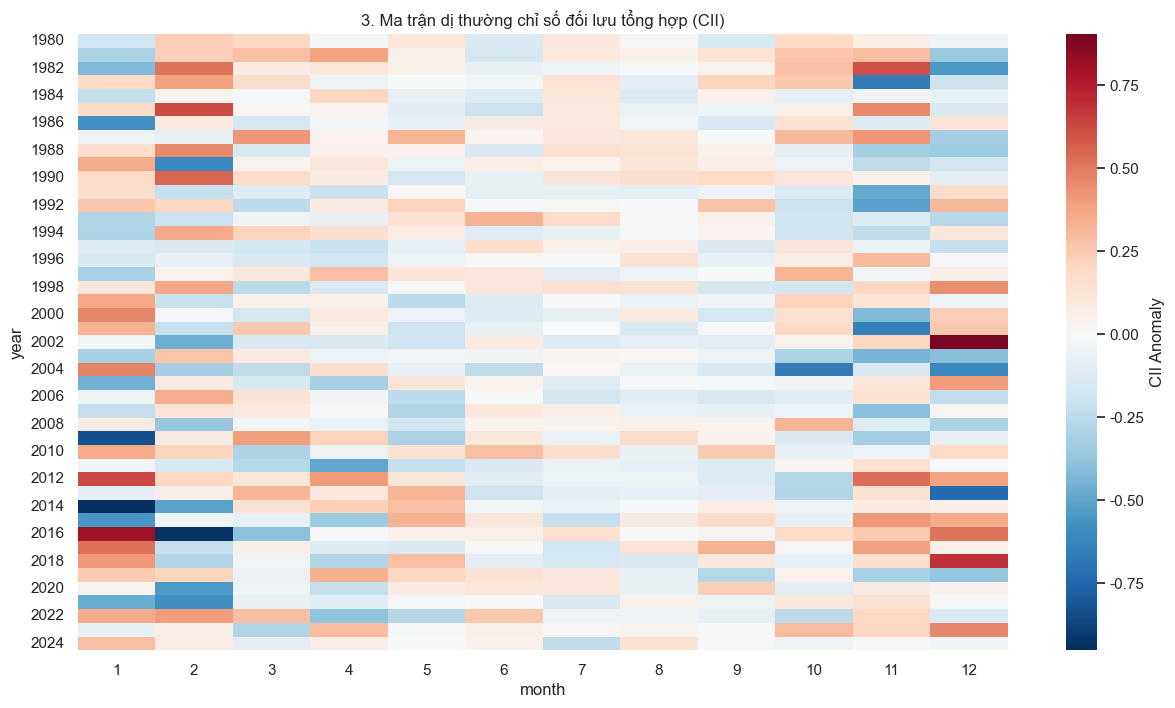

In [21]:
pivot = df_monthly.pivot(index='year', columns='month', values='cii_anom')
plt.figure(figsize=(15, 8))
sns.heatmap(pivot, cmap="RdBu_r", center=0, cbar_kws={'label': 'CII Anomaly'})
plt.title("3. Ma trận dị thường chỉ số đối lưu tổng hợp (CII)")
plt.show()

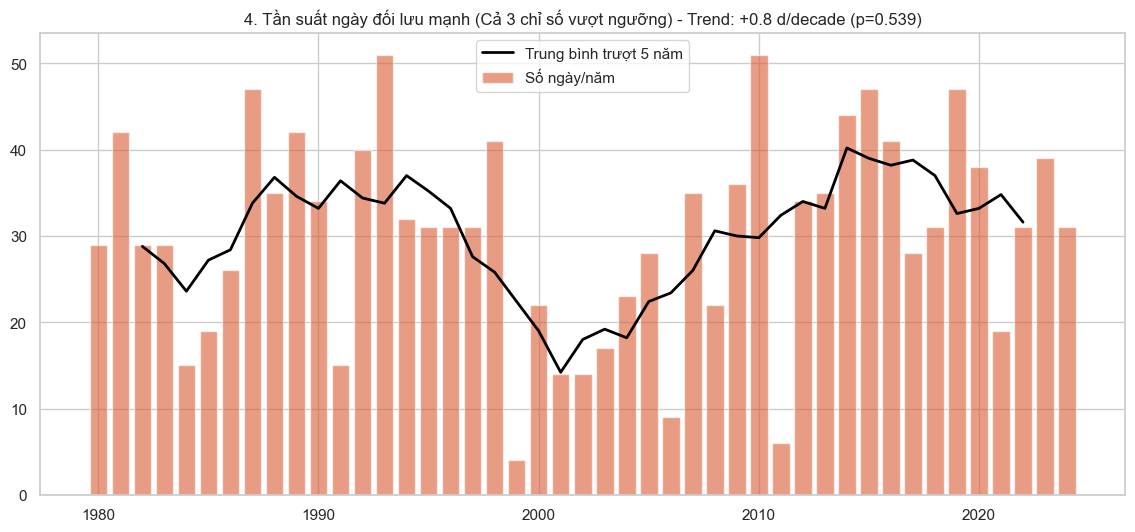

In [22]:
annual_sev = df_daily['severe'].resample('YS').sum()
x = annual_sev.index.year
y = annual_sev.values

plt.figure(figsize=(14, 6))
plt.bar(x, y, color='#D85A30', alpha=0.6, label='Số ngày/năm')
plt.plot(x, pd.Series(y).rolling(5, center=True).mean(), color='black', lw=2, label='Trung bình trượt 5 năm')
slope, _, _, p, _ = stats.linregress(x, y)
plt.title(f"4. Tần suất ngày đối lưu mạnh (Cả 3 chỉ số vượt ngưỡng) - Trend: {slope*10:+.1f} d/decade (p={p:.3f})")
plt.legend()
plt.show()

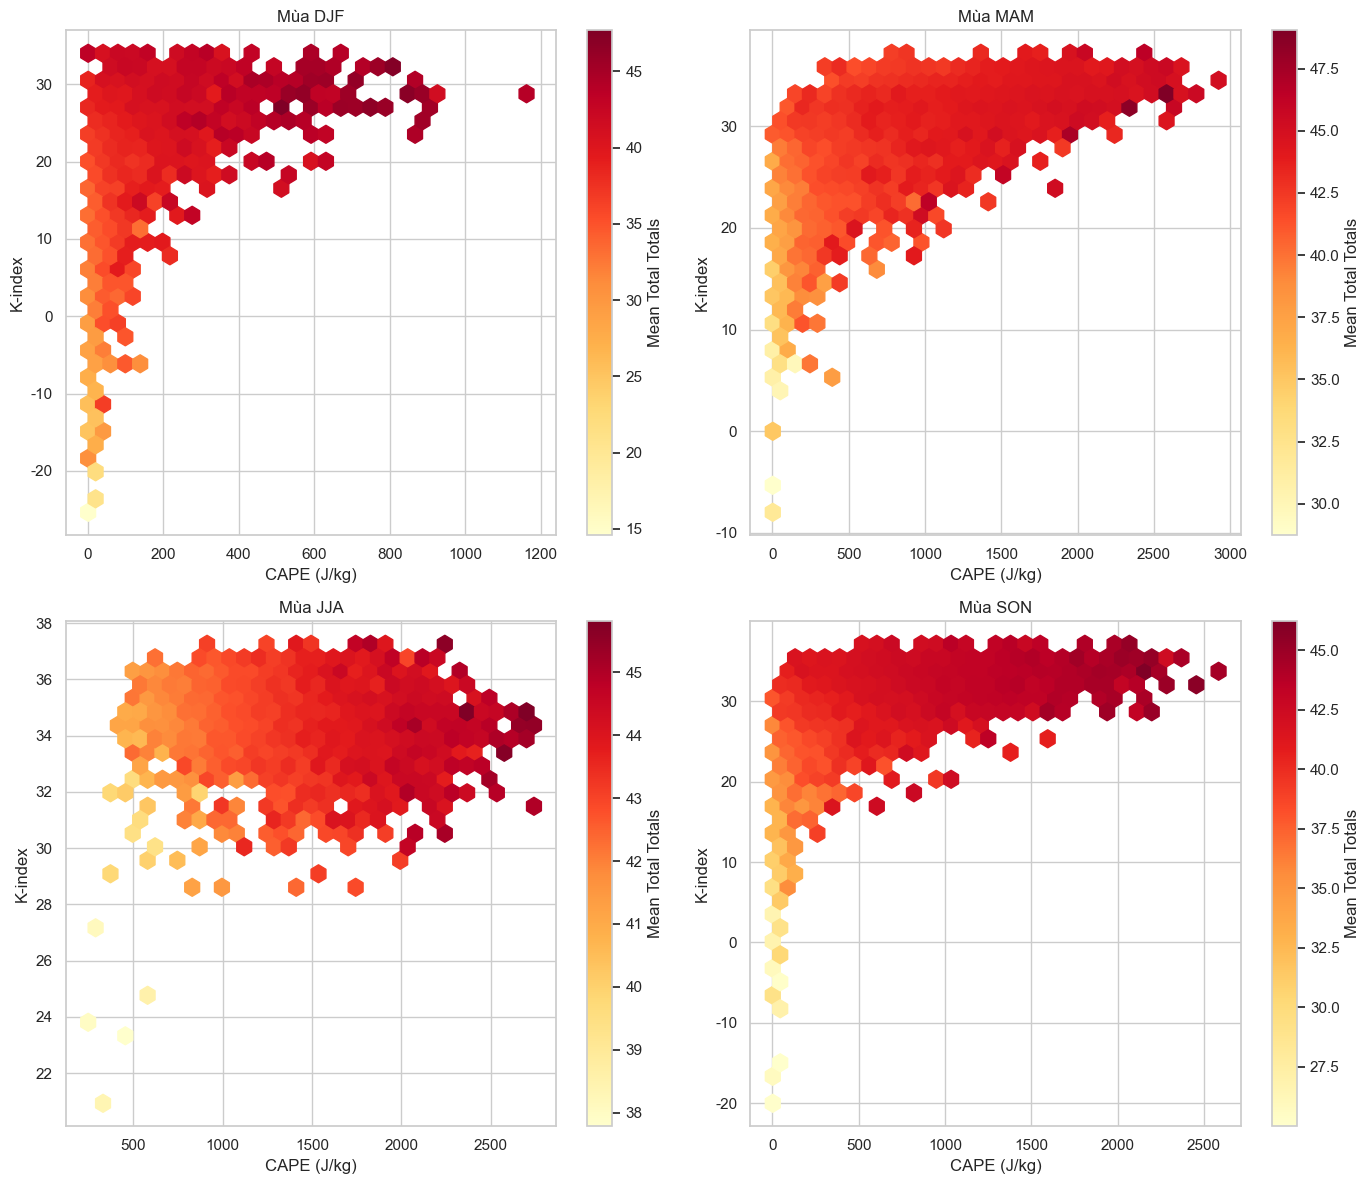

In [23]:
df_daily['month'] = df_daily.index.month
df_daily['season'] = df_daily['month'].map({12:'DJF', 1:'DJF', 2:'DJF', 3:'MAM', 4:'MAM', 5:'MAM', 6:'JJA', 7:'JJA', 8:'JJA', 9:'SON', 10:'SON', 11:'SON'})

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, season in zip(axes.flatten(), ['DJF', 'MAM', 'JJA', 'SON']):
    subset = df_daily[df_daily['season'] == season]
    hb = ax.hexbin(subset['cape'], subset['ki'], C=subset['tt'], gridsize=30, cmap='YlOrRd')
    ax.set_title(f"Mùa {season}")
    ax.set_xlabel("CAPE (J/kg)")
    ax.set_ylabel("K-index")
    plt.colorbar(hb, ax=ax, label='Mean Total Totals')
plt.tight_layout()
plt.show()

In [24]:
try:
    df_t2m = pd.read_csv(os.path.join(folder_path, 'df_monthly_t2m.csv'), index_col=0, parse_dates=True)
    df_td = pd.read_csv(os.path.join(folder_path, 'df_monthly_td.csv'), index_col=0, parse_dates=True)
    
    df_reg = pd.DataFrame({
        'cape_anom': df_monthly['cape_anom'],
        't2m_anom': df_t2m['t2m_anom'],
        'td_anom': df_td['td_anom']
    }).dropna()
    
    model = LinearRegression().fit(df_reg[['t2m_anom', 'td_anom']], df_reg['cape_anom'])
    
    plt.figure(figsize=(8, 5))
    plt.bar(['Nhiệt độ (T2m)', 'Điểm sương (Td)'], model.coef_, color=['#D85A30', '#185FA5'])
    plt.title(f"6. Phân tách đóng góp vào xu hướng CAPE (R²={model.score(df_reg[['t2m_anom', 'td_anom']], df_reg['cape_anom']):.2f})")
    plt.ylabel("Hệ số hồi quy (J/kg per K)")
    plt.show()
except:
    print("Cần dữ liệu T2m và Td từ NB 01/03 để chạy Plot 6")

Cần dữ liệu T2m và Td từ NB 01/03 để chạy Plot 6


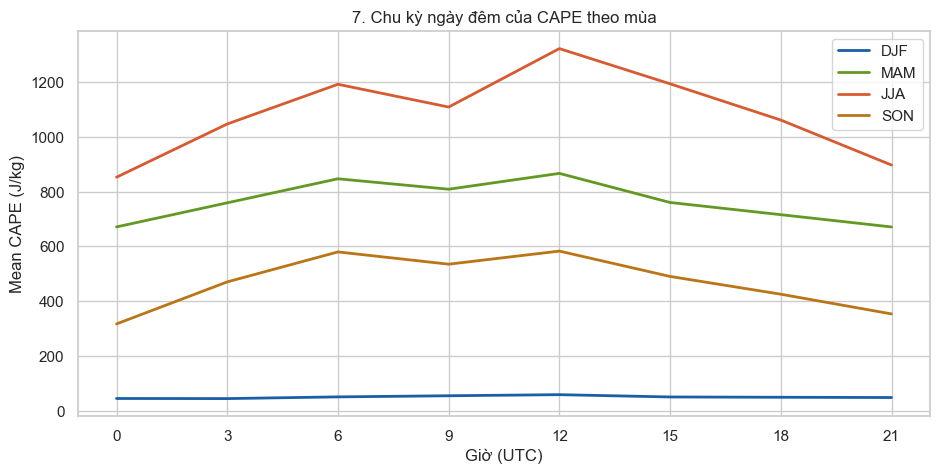

In [25]:
cape_raw = raw['cape']
seasons = {'DJF': [12,1,2], 'MAM': [3,4,5], 'JJA': [6,7,8], 'SON': [9,10,11]}
colors = {'DJF': '#185FA5', 'MAM': '#639922', 'JJA': '#D85A30', 'SON': '#BA7517'}

plt.figure(figsize=(11, 5))
for s_name, s_months in seasons.items():
    subset = cape_raw.sel(time=cape_raw.time.dt.month.isin(s_months))
    diurnal = subset.groupby('time.hour').mean()
    plt.plot(diurnal.hour, diurnal.values, color=colors[s_name], lw=2, label=s_name)

plt.title("7. Chu kỳ ngày đêm của CAPE theo mùa")
plt.xlabel("Giờ (UTC)")
plt.ylabel("Mean CAPE (J/kg)")
plt.xticks(range(0, 24, 3))
plt.legend()
plt.show()

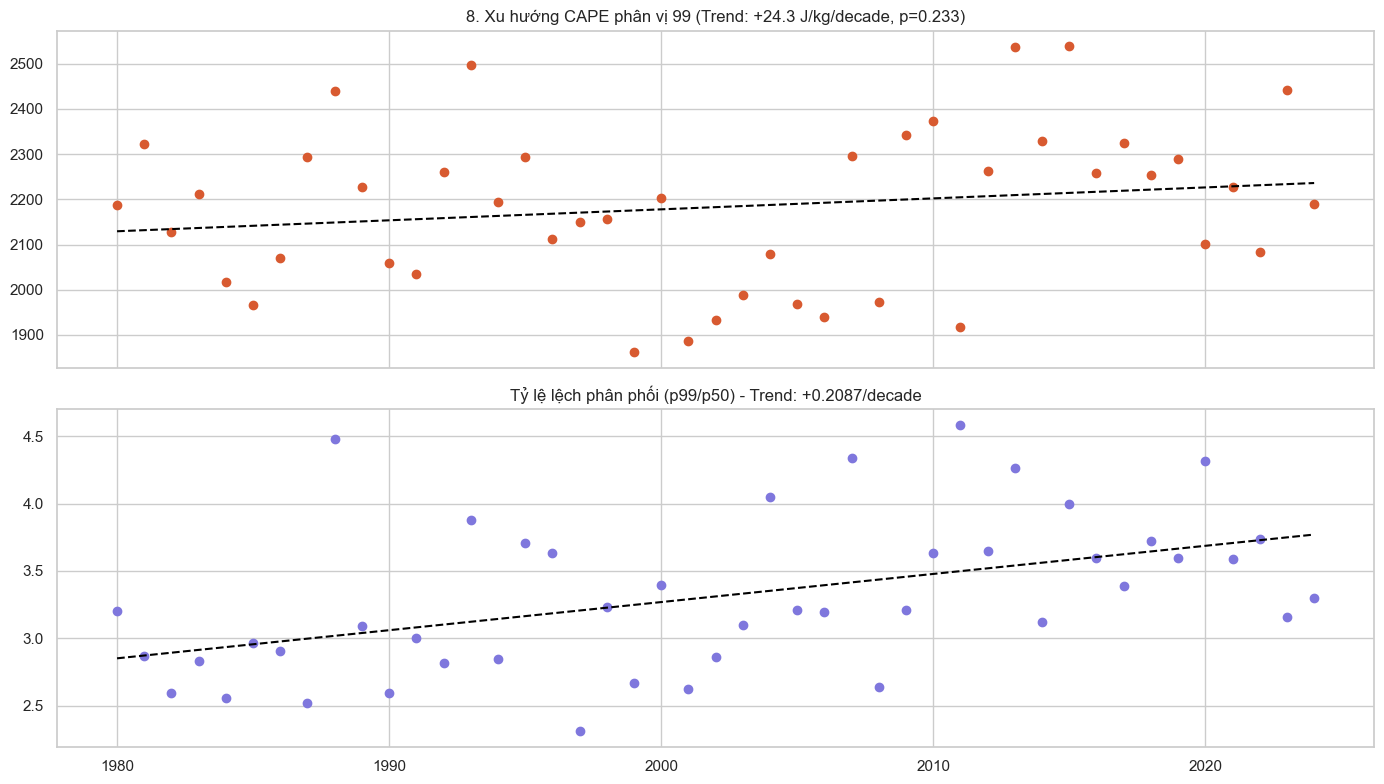

In [27]:
p99 = df_daily['cape'].resample('YS').quantile(0.99)
p50 = df_daily['cape'].resample('YS').quantile(0.50)
skew = p99 / (p50 + 1e-9)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
years = p99.index.year
sl1, ic1, _, p1, _ = stats.linregress(years, p99.values)
ax1.scatter(years, p99.values, color='#D85A30')
ax1.plot(years, ic1 + sl1 * years, color='black', ls='--')
ax1.set_title(f"8. Xu hướng CAPE phân vị 99 (Trend: {sl1*10:+.1f} J/kg/decade, p={p1:.3f})")

sl2, ic2, _, p2, _ = stats.linregress(years, skew.values)
ax2.scatter(years, skew.values, color='#7F77DD')
ax2.plot(years, ic2 + sl2 * years, color='black', ls='--')
ax2.set_title(f"Tỷ lệ lệch phân phối (p99/p50) - Trend: {sl2*10:+.4f}/decade")
plt.tight_layout()
plt.show()

In [28]:
df_daily[['cii', 'severe']].to_csv(os.path.join(folder_path, 'derived_instability_daily.csv'))